## Data Loading and Initial Exploration

### Subtask: Importing Needed Libraries
I start by importing standard Python libraries for data science:

`pandas` for data manipulation
`numpy` for numerical operations.

`matplotlib.pyplot` and `seaborn` for plotting (`%matplotlib inline` ensures plots are displayed directly in the notebook).

I also import modules from sklearn for preprocessing (`mean_squared_error`, `StratifiedKFold`, `train_test_split`, `LabelEncoder`) and models (`LinearRegression`, `Ridge`, `xgboost`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# importing some minor Libraries  that will help my life
#import textwrap
#from ast import Break

# Importing libraries that help with preprocessing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# importing the models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
import xgboost as xgb


### Subtask: Importing the dataset.
I will load the train.csv and test.csv files into pandas DataFrames named train_df and test_df respectively. Next I display the first 5 rows of train_df using display(train_df.head()) to give a quick overview of its structure and content.

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200.0
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999.0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900.0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000.0
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500.0


## Exploratory Data Analysis

### Subtask:
Explore the data and gather some basic informaton on the dataset columns.
The command `train_df.info` is invaluable for getting a quick summary of the DataFrame, including:

The number of entries (rows).

The number of columns.

Each column's name.

The number of non-null values in each column (which helps identify columns with missing data).

The data type (Dtype) of each column (e.g., int64, object).

Memory usage.


In [ ]:
# @title
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121129 entries, 0 to 121128
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            121129 non-null  int64  
 1   brand         121129 non-null  object 
 2   model         121129 non-null  object 
 3   model_year    121129 non-null  int64  
 4   milage        121129 non-null  int64  
 5   fuel_type     117885 non-null  object 
 6   engine        121128 non-null  object 
 7   transmission  121128 non-null  object 
 8   ext_col       121128 non-null  object 
 9   int_col       121128 non-null  object 
 10  accident      119557 non-null  object 
 11  clean_title   107390 non-null  object 
 12  price         121128 non-null  float64
dtypes: float64(1), int64(3), object(9)
memory usage: 12.0+ MB


**Observations:** From the output of train_df.info();

`fuel_type` has 183450 non-null values out of 188533 total, indicating some missing values.

`accident` has 186081 non-null values, also indicating missing values.

`clean_title` has 167114 non-null values, suggesting a significant portion of missing data.

Most columns are of object type (categorical strings) or int64 (numerical integers).

### Subtask:
Visualize the numerical variables of train_df using a pairplot.

The pairplot is a grid of scatterplots for numerical columns and histograms for each numerical column's distribution. This helps visualize relationships between numerical features and their individual distributions.

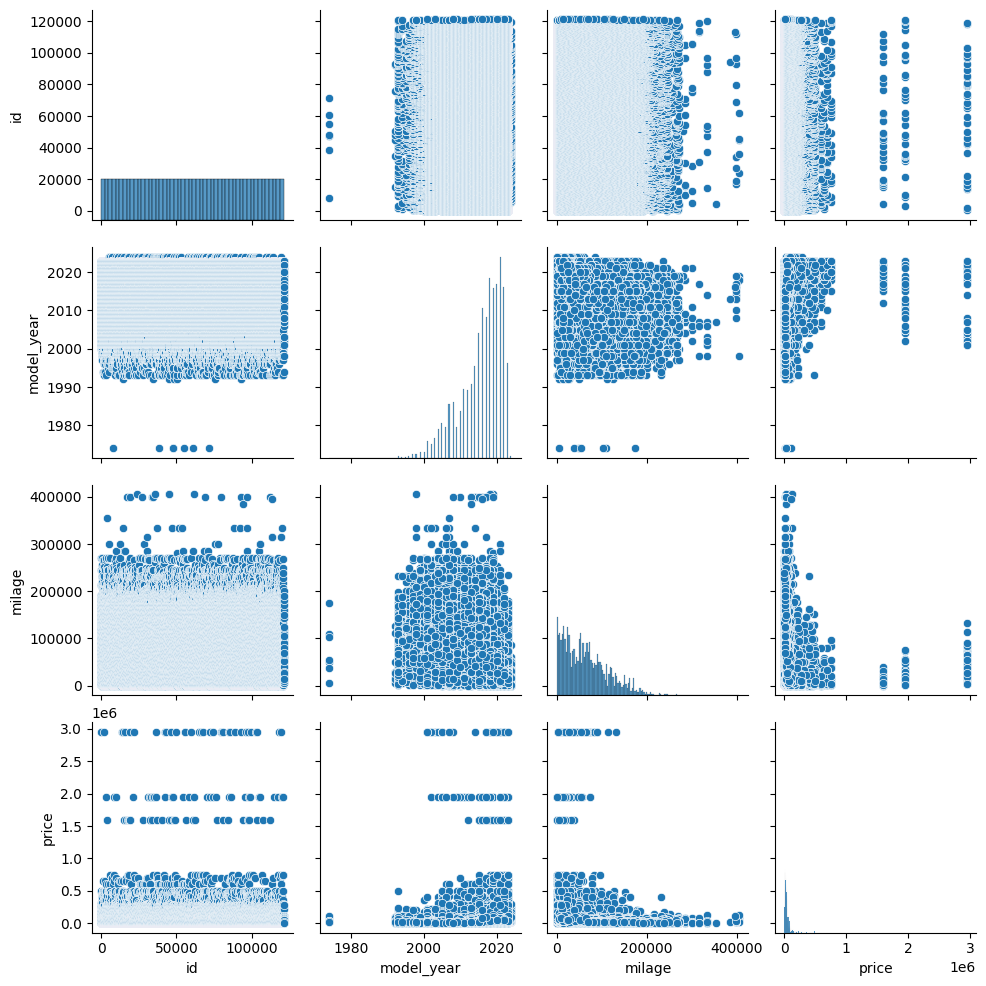

In [ ]:
# @title
sns.pairplot(train_df)
plt.show()

**Observations:**
Results show that model_year and milage are skewed to the left and the right respectively.
We also see some sort of negative correlation between milage and price. Slight positive correlation between model_year and price.

**Reasoning:** To get a closer and detailed view at the relationships, consider the scatterplot of `milage` vs `price` vs `model_year`

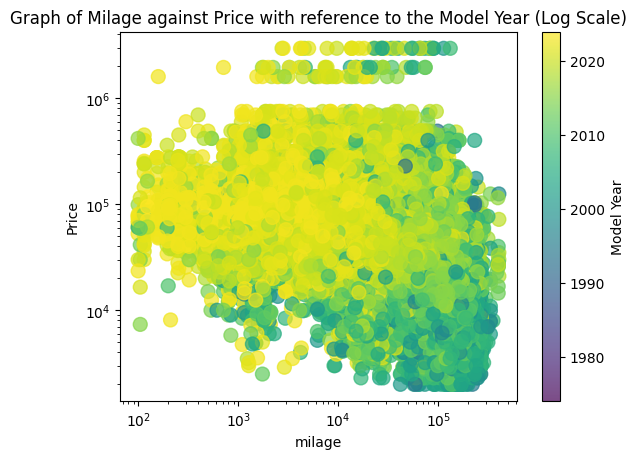

In [ ]:
# @title
scatter = plt.scatter(train_df['milage'],train_df["price"], c=train_df["model_year"], cmap='viridis', s=100, alpha=0.7)
plt.colorbar(scatter, label='Model Year')
plt.xlabel("milage")
plt.ylabel("Price")
plt.xscale('log')
plt.yscale('log')
plt.title("Graph of Milage against Price with reference to the Model Year (Log Scale)")
plt.show()

## **Observation:**

Age (Model Year) is a Dominant Factor in Depreciation: The most consistent insight is that newer cars are significantly more valuable. Even when comparing cars with similar mileage, newer models fetch higher prices. This suggests that factors like technological advancements, safety features, modern aesthetics, warranty status (for recent used cars), and general market perception of 'newness' contribute heavily to a car's value, often outweighing mileage to a certain extent.

Mileage's Impact is Strong but Context-Dependent: While lower mileage generally correlates with higher prices, its influence is mitigated by age. An older car with low mileage might still be priced lower than a newer car with higher mileage, indicating that wear and tear due to age (e.g., rubber degradation, component aging) and perceived obsolescence contribute to depreciation independently of actual distance driven.

Collector's Items/Classics: Some older vehicles, especially certain brands or models, might appreciate or hold significant value due to their rarity, historical significance, or classic status, even with high mileage.

Note: The relationships aren't always linear. Instead, age, mileage, and likely other unobserved factors (eg strong brand loyalty, maintenance history etc) interact in complex ways to determine the final price. This highlights the importance of considering multiple variables simultaneously when predicting car prices.


## **Observation:**

Age (Model Year) is a Dominant Factor in Depreciation: The most consistent insight is that newer cars are significantly more valuable. Even when comparing cars with similar mileage, newer models fetch higher prices. This suggests that factors like technological advancements, safety features, modern aesthetics, warranty status (for recent used cars), and general market perception of 'newness' contribute heavily to a car's value, often outweighing mileage to a certain extent.

Mileage's Impact is Strong but Context-Dependent: While lower mileage generally correlates with higher prices, its influence is mitigated by age. An older car with low mileage might still be priced lower than a newer car with higher mileage, indicating that wear and tear due to age (e.g., rubber degradation, component aging) and perceived obsolescence contribute to depreciation independently of actual distance driven.

Collector's Items/Classics: Some older vehicles, especially certain brands or models, might appreciate and hold significant value due to their rarity, historical significance, or classic status, even with high mileage.

Note: The relationships aren't always linear. Instead, age, mileage, and likely other unobserved factors (eg strong brand loyalty, maintenance history etc) interact in complex ways to determine the final price. This highlights the importance of considering multiple variables simultaneously when predicting car prices.

### **Recommendations for More Accurate Modeling:**

Based on these observations, here are some crucial strategies for more accurate modeling:

*   **Feature Engineering for Age/Model Year:** Create new features such as the 'age of the car' (`current_year - model_year`) and consider log transformations for 'age' and 'milage' to capture non-linear impacts on price.
*   **Stratification or Segmentation:** Given potential 'niche markets' (e.g., collector's items), consider training separate models for different segments of cars or explicitly handling these distinct groups.
*   **Interaction Terms:** Investigate the use of interaction terms (e.g., `milage * age`) to capture the combined effects of mileage and age on price.
*   **Robust Models/Outlier Handling:** Employ models that are robust to outliers (like tree-based models such as XGBoost) or develop specific strategies to identify and handle anomalous data points that deviate significantly from general trends.

### Subtask
 To further understand the distribution of values within each categorical and numerical column, its crucial to plot the value counts of all column, aside the id column.
It helps in Identifying unique values, checking for imbalance, spotting anomalies/outliers, assessing data quality and feature engineering clues.

In [ ]:
import textwrap

# This is the main function
def plot_train_df_valuecounts(dataframe):
    """
    This function plots the value counts for both numeric and categorical columns
    in a DataFrame. It automatically handles text wrapping for object (categorical) columns.
    """
    for column in dataframe.columns:
        print(f"Plotting graph for {column}")

        index_counts = dataframe[column].value_counts()
        index_val = index_counts.index
        value_val = index_counts.values

        if pd.api.types.is_object_dtype(dataframe[column]):
            # Apply text wrapping for object (categorical) column labels
            index_val = [textwrap.fill(str(label), 7) for label in index_counts.index]

        plt.figure(figsize=(10, 6)) # Create a new figure for each plot to prevent overlap
        plt.bar(index_val, value_val)
        plt.xlabel(column)
        plt.ylabel('count')
        plt.title(f'{column} value counts')
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
        plt.tight_layout() # Adjust layout to prevent labels from being cut off
        plt.show()


Plotting graph for brand


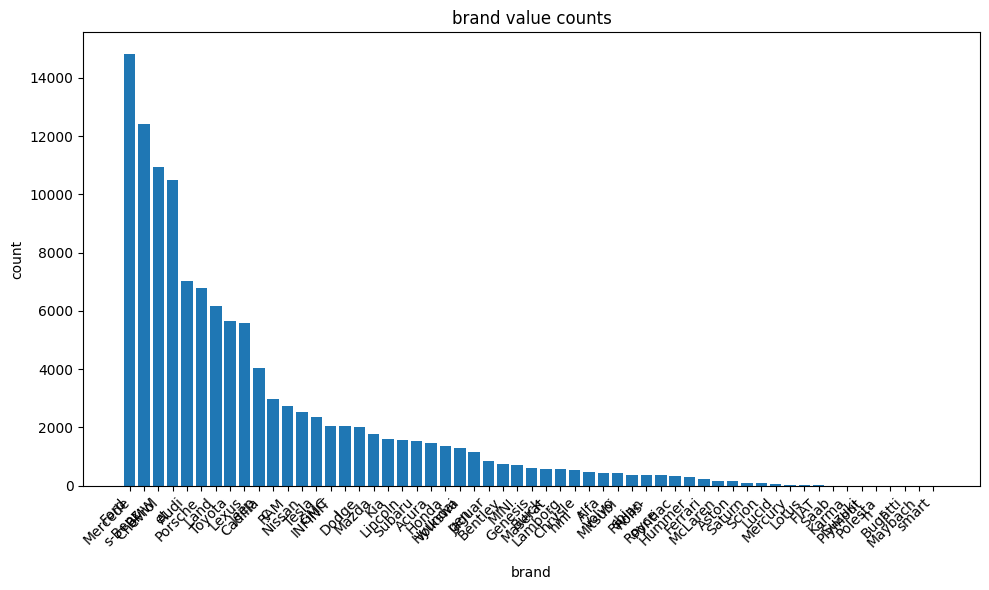

Plotting graph for model


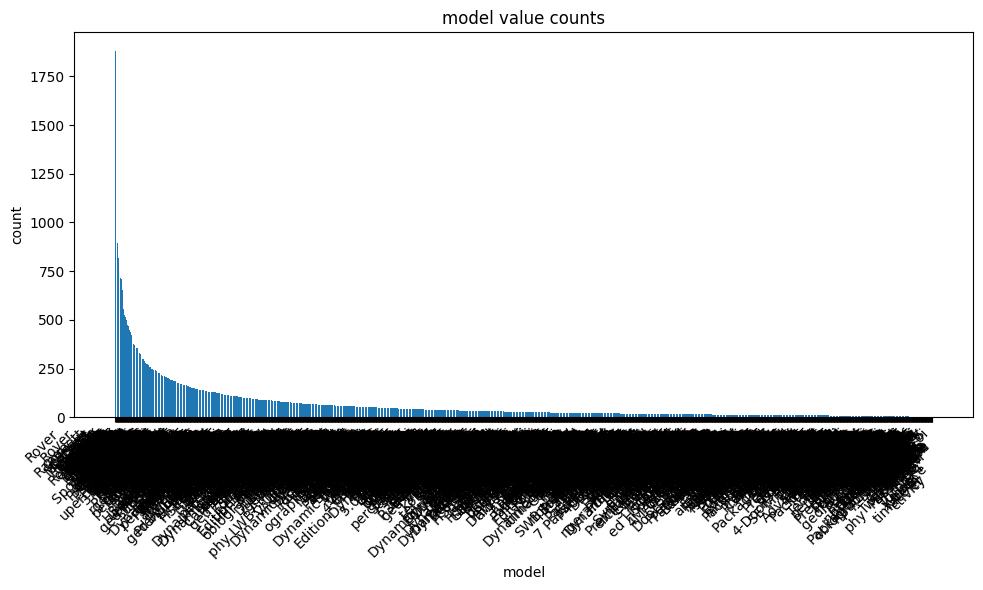

Plotting graph for model_year


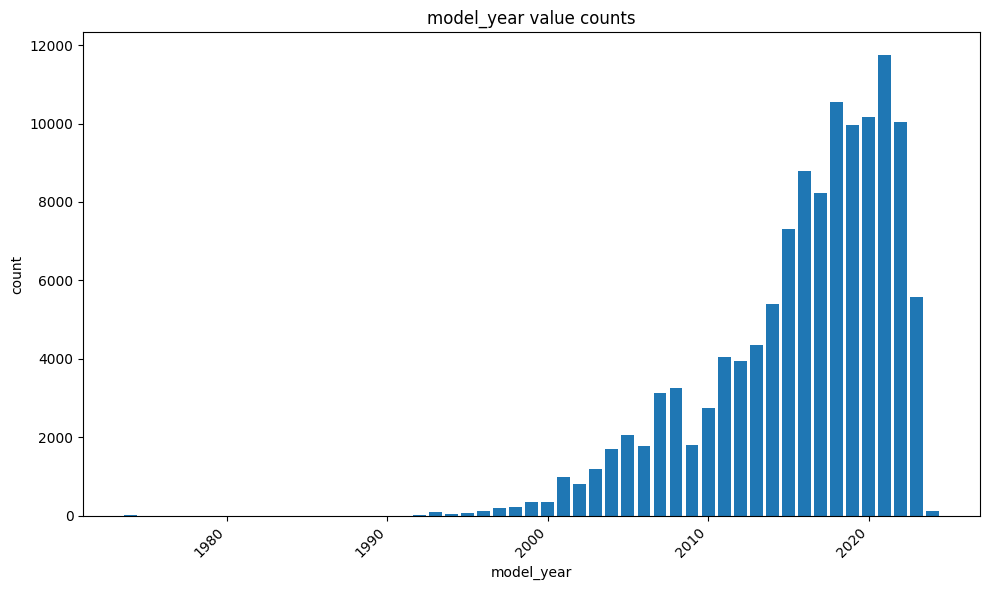

Plotting graph for milage


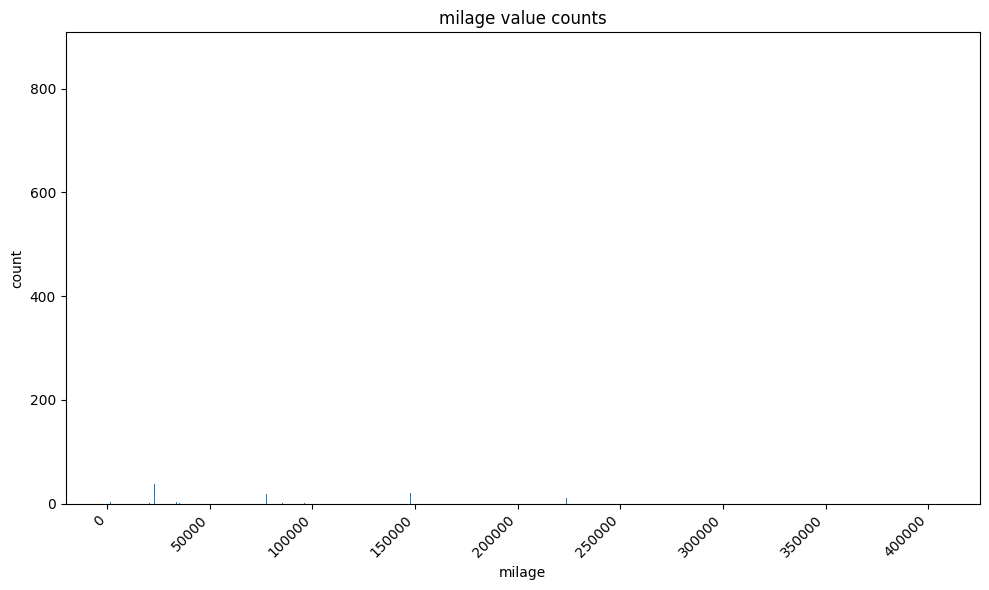

Plotting graph for fuel_type


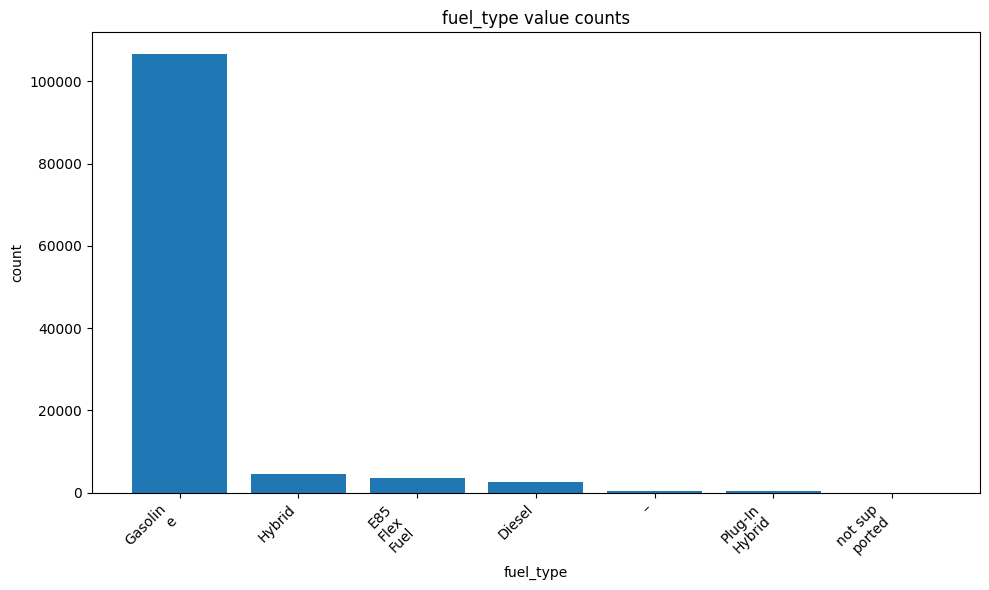

Plotting graph for engine


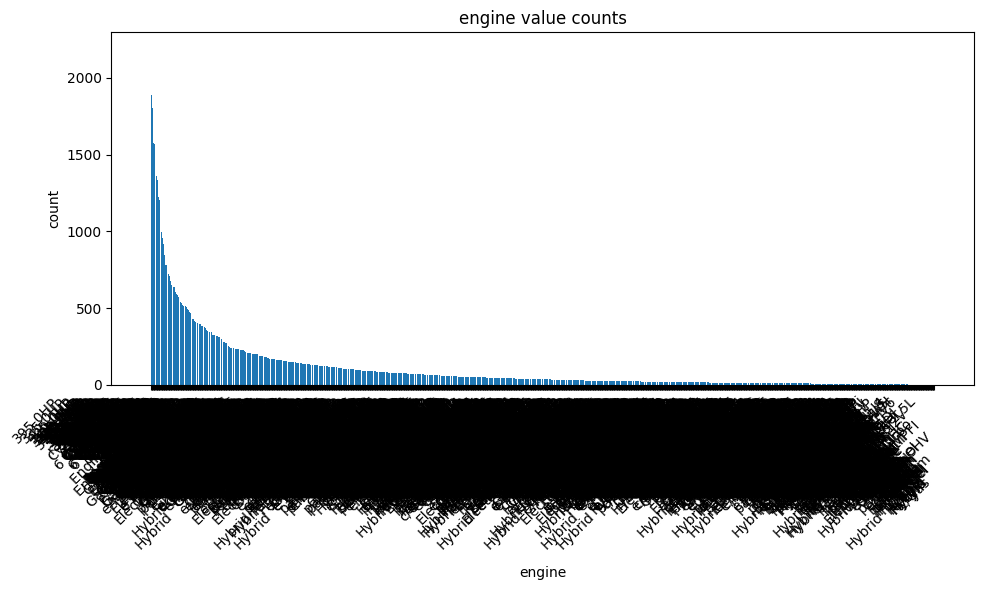

Plotting graph for transmission


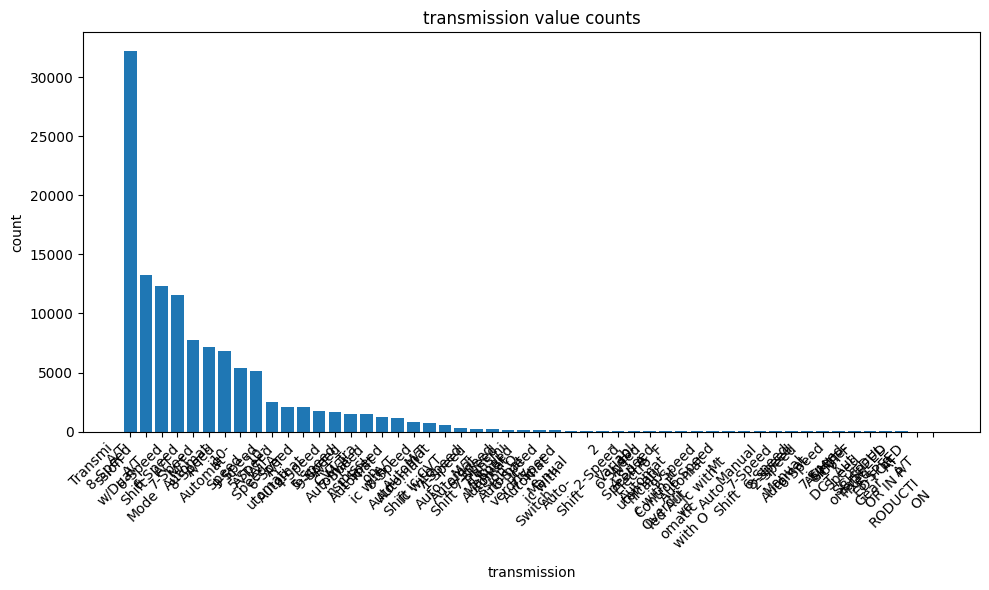

Plotting graph for ext_col


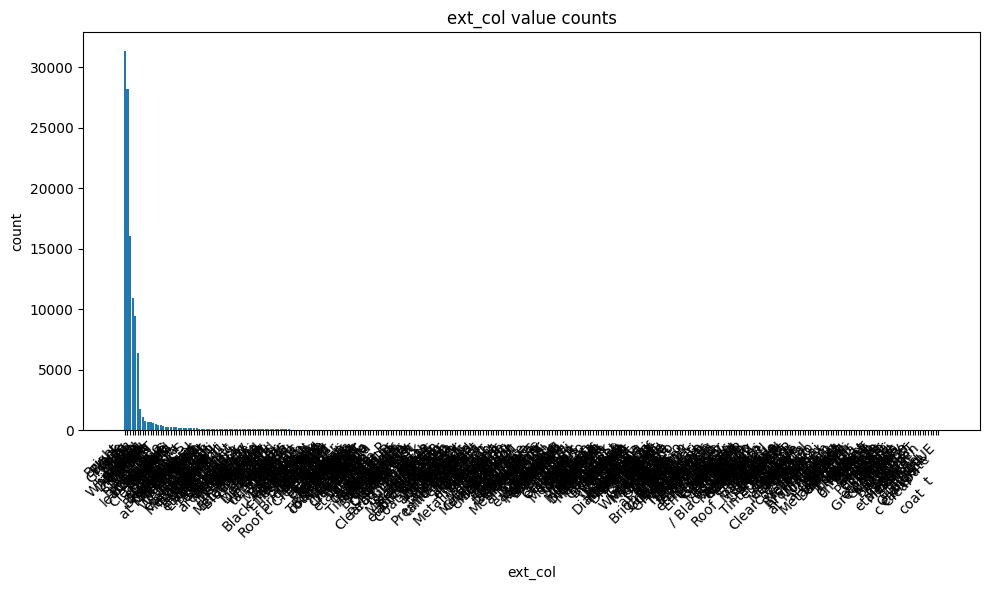

Plotting graph for int_col


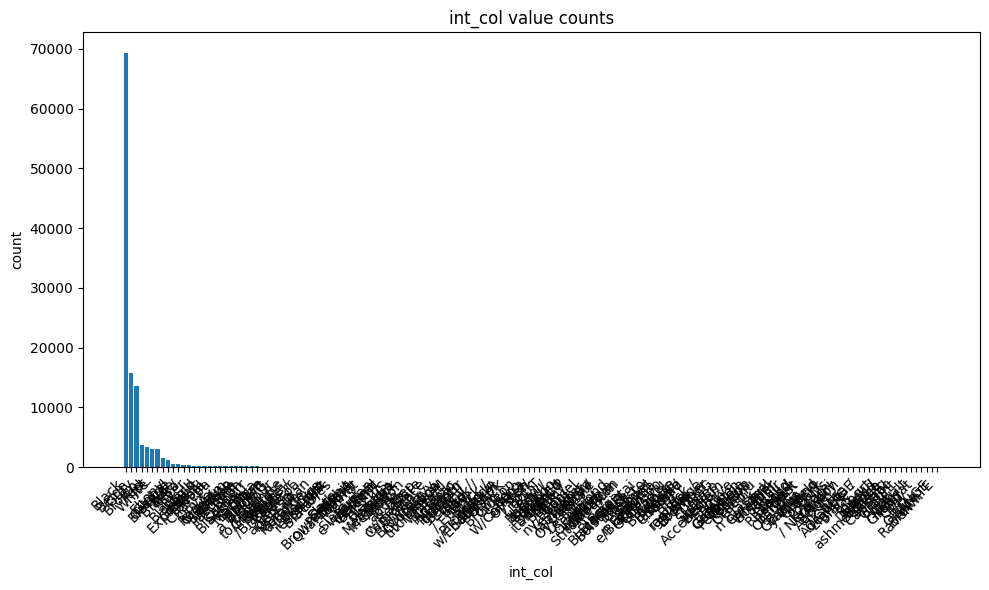

Plotting graph for accident


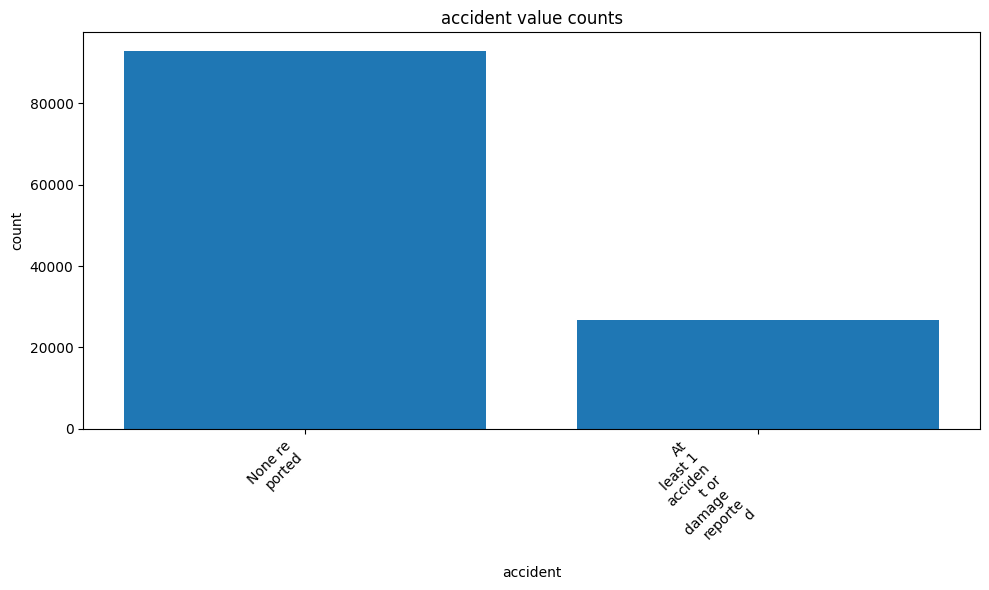

Plotting graph for clean_title


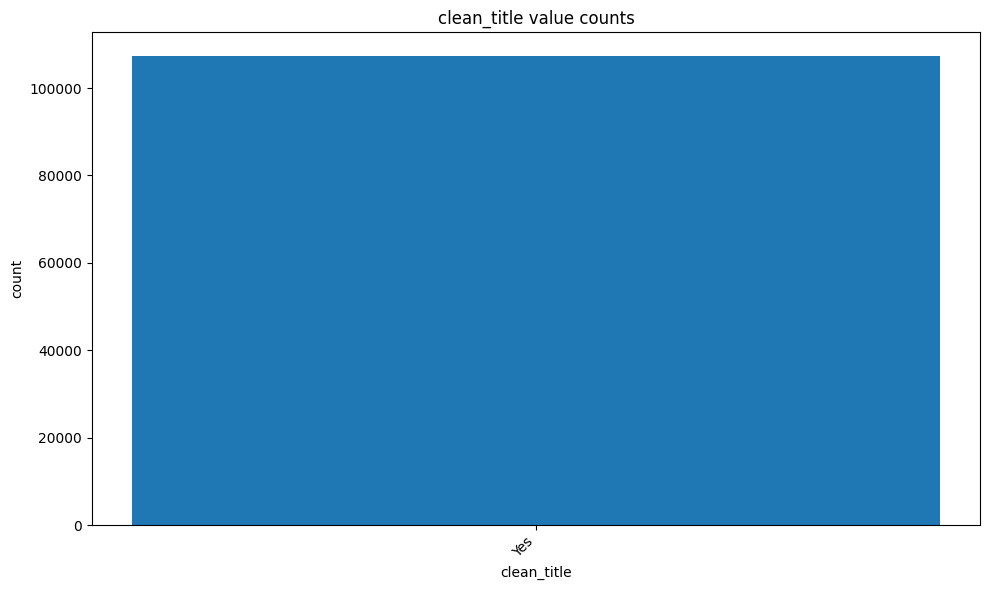

Plotting graph for price


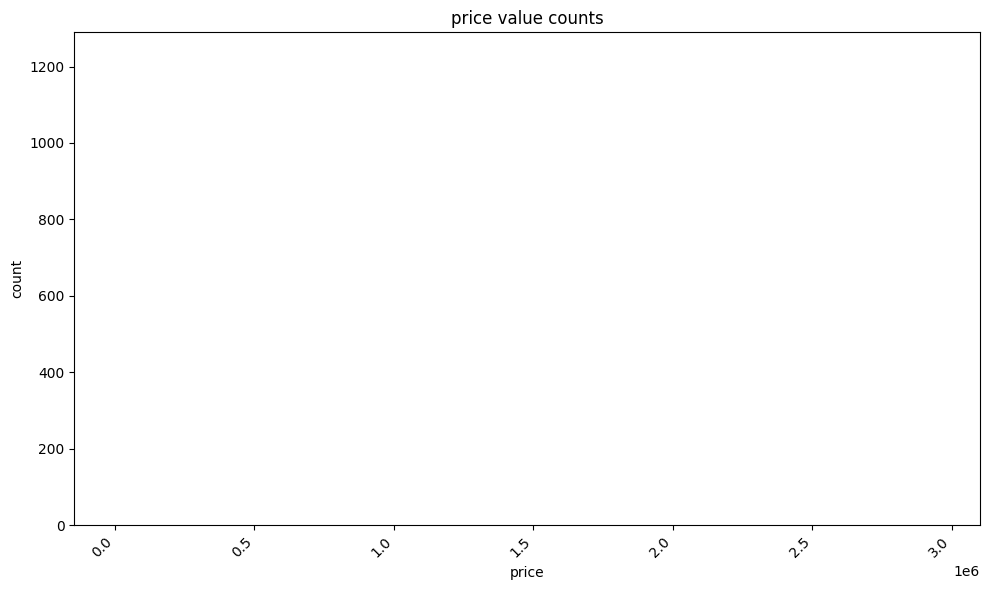

In [ ]:
train_df_values = train_df.drop(columns = "id", axis = 1)
plot_train_df_valuecounts(train_df_values)

**Observations:**

`model_year` Outliers: There are cars manufactured before 1980 which are identified as potential outliers. These might need special handling or investigation.

`clean_title` Column: This column appears to have only one unique value across all entries. This means it provides no discriminative information for the model and should be dropped during data cleaning.

Imbalanced Categorical Features: Both the `fuel_type` and `accident` columns show significant imbalance. For example, most vehicles use 'gasoline' fuel. This imbalance suggests that when splitting data for training and validation, stratified sampling might be beneficial to ensure representative distributions of these categories.

`engine` Column for Feature Engineering: The engine column contains rich, structured information (e.g., horsepower, engine size in liters, number of cylinders, and specific engine type) embedded within a single string. This is a prime candidate for feature engineering to extract these numerical and categorical details into separate, usable features.

## Data PreProcessing and Feature Engineering

### Feature Engineering: Age and Interaction Term

I will create two new features:
1.  **`car_age`**: Calculated as `current_year - model_year`. For `current_year`, I'll use 2023 as a reasonable estimate.
2.  **`milage_age_interaction`**: An interaction term by multiplying `milage` and `car_age`.

These features will be added to both the `train_df` and `test_df`.

In [ ]:
# @title
# Assume current year for age calculation
CURRENT_YEAR = 2023

# Create 'car_age' feature for both dataframes
train_df['car_age'] = CURRENT_YEAR - train_df['model_year']
test_df['car_age'] = CURRENT_YEAR - test_df['model_year']

# Create 'milage_age_interaction' feature for both dataframes
train_df['milage_age_interaction'] = train_df['milage'] * train_df['car_age']
test_df['milage_age_interaction'] = test_df['milage'] * test_df['car_age']

display(train_df.head())
display(test_df.head())

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,milage_age_interaction
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200.0,16,3408000
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999.0,21,3008250
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900.0,21,2871351
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000.0,6,117000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500.0,2,14776


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,car_age,milage_age_interaction
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes,8,784000
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes,3,27426
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN,1,28121
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN,7,428806
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes,5,295000


### Subtask
Apply feature engineering to the `engine` column.

**Reasoning:** First examine the typical content of the `engine` column, using the `value_counts` function

In [ ]:
print(train_df['engine'].value_counts())

engine
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel           2187
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel           1886
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel           1806
2.0L I4 16V GDI DOHC Turbo                             1744
340.0HP 3.0L V6 Cylinder Engine Gasoline Fuel          1575
                                                       ... 
70.0HP 1.0L 3 Cylinder Engine Gasoline Fuel               1
141.0HP 2.0L 4 Cylinder Engine Gasoline Fuel              1
266.0HP 2.5L 4 Cylinder Engine Plug-In Electric/Gas       1
111.0HP Electric Motor Electric Fuel System               1
3.8L V6 12V MPFI OHV                                      1
Name: count, Length: 1111, dtype: int64


##### Task
Biuld a pipeline that extracts information from the engine columns to make it focused on one variable.


In [ ]:
import re
def engine_restructure(df, col='engine'):
  pattern = (
    r'(?P<Horsepower>\d+\.?\d*HP)?\s*'           #Optional Hp
    r'(?P<Displacemt>\d+\.?\d*L)?\s*'            #Optional Displacemt
    r'(?:(?P<Cylinders>\d+|V\d+|I\d+)s*)?'     #Optional Cylinders
    r'(?:Cylinder\s*)?'                          #Optional Cylinder word
    r'(?:Engine\s*)?'                            #Optional Engine word
    r'(?P<Engine_type>.*)?'                      #Optional Engine type
  )

  extracted = df[col].str.extract(pattern, flags=re.IGNORECASE)

  # Normalize cylinders early
  extracted['Cylinders'] = extracted['Cylinders'].replace(
      [r'^V', r'^I'], ['', ''], regex=True).where(
          extracted['Cylinders'].notna(), pd.NA)

  # Prefer explicit Engine Type, fallback to Gasoline
  extracted['Engine_type'] = extracted['Engine_type'].str.strip().mask(lambda x : x=='', 'Gasoline Fuel')

  #Keep only desired columns + fill sensible defaults
  results = pd.DataFrame({
      'Horsepower': extracted['Horsepower'].str.replace('HP', '', regex=False),
      'Displacemt': extracted['Displacemt'].str.replace('L', '', regex=False),
      'Cylinders' : extracted['Cylinders'],
      'Engine_type': extracted['Engine_type']
  })

  return pd.concat([df, results], axis=1)


In [ ]:
# Running the function on train_df
train_dfc = engine_restructure(train_df, "engine")
test_dfc = engine_restructure(test_df, "engine")

# Checking the added columns
train_dfc.info()
test_dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121129 entries, 0 to 121128
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      121129 non-null  int64  
 1   brand                   121129 non-null  object 
 2   model                   121129 non-null  object 
 3   model_year              121129 non-null  int64  
 4   milage                  121129 non-null  int64  
 5   fuel_type               117885 non-null  object 
 6   engine                  121128 non-null  object 
 7   transmission            121128 non-null  object 
 8   ext_col                 121128 non-null  object 
 9   int_col                 121128 non-null  object 
 10  accident                119557 non-null  object 
 11  clean_title             107390 non-null  object 
 12  price                   121128 non-null  float64
 13  car_age                 121129 non-null  int64  
 14  milage_age_interacti

**Observation:**
There is a high number of null entries for especially `Horsepower` and `Cylinders` columns.
We'll get to this later on.

### Task
Declutter and clean the `transmssion` column

In [ ]:
# First review the column
print(train_df['transmission'].value_counts())


transmission
A/T                                                   32174
8-Speed A/T                                           13280
Transmission w/Dual Shift Mode                        12314
6-Speed A/T                                           11593
6-Speed M/T                                            7732
7-Speed A/T                                            7139
Automatic                                              6858
8-Speed Automatic                                      5378
10-Speed A/T                                           5130
9-Speed A/T                                            2508
5-Speed A/T                                            2053
10-Speed Automatic                                     2041
6-Speed Automatic                                      1786
4-Speed A/T                                            1651
5-Speed M/T                                            1519
9-Speed Automatic                                      1503
CVT Transmission           

In [ ]:
def split_transmission(df, column):
    # Create a copy to avoid modifying the original DataFrame inadvertently
    temp_df = df.copy()

    # Step 1: Extract leading numbers as potential Speeds, and the rest of the string
    # This handles standalone numbers like '2' or '53' that aren't followed by "Speed"
    initial_extract_pattern = r'^\s*(?P<Initial_Speed_Num>\d+)?\s*(?P<Remainder>.*)$'
    extracted_initial = temp_df[column].str.extract(initial_extract_pattern, flags=re.IGNORECASE)

    # Step 2: Parse the 'Remainder' for actual transmission type keywords and any remaining extras
    type_extras_pattern = (
        r'(?:-Speed|\s*Speed|\s*A/T|\s*M/T)?\s*' # Optional "Speed" or "A/T"/"M/T" that might follow a number
        r'(?P<Type_Extracted>Automatic|A/T|M/T|Manual|CVT|DCT|E-CVT|Shiftronic|Autostick|Tiptronic|Variable)?' # Optional main type
        r'\s*(?P<Extras_Raw>.*)' # Any remaining description
    )
    extracted_type_extras = extracted_initial['Remainder'].str.extract(type_extras_pattern, flags=re.IGNORECASE)

    # --- Consolidation and Normalization ---
    results_df = pd.DataFrame(index=temp_df.index)
    results_df["Speeds"] = pd.to_numeric(extracted_initial["Initial_Speed_Num"], errors='coerce')

    # Normalize transmission type abbreviations and strip whitespace
    results_df["transmission_Type"] = extracted_type_extras["Type_Extracted"].replace({
        "A/T": "Automatic",
        "M/T": "Manual",
        "E-CVT": "CVT", # Treat E-CVT as CVT
        "Shiftronic": "Automatic", # Shiftronic is a type of automatic transmission
        "Autostick": "Automatic",
        "Tiptronic": "Automatic"
    }).str.strip()

    # Apply rule-based overrides for DCT, which might be described in various ways
    mask_dct = temp_df[column].str.contains("Dual Shift Mode|Auto-Shift|dual clutch", case=False, na=False)
    results_df.loc[mask_dct, "transmission_Type"] = "DCT"

    # Fallback for transmission_Type: if it's still NaN, try to infer from original string
    mask_auto_fallback = results_df['transmission_Type'].isna() & temp_df[column].str.contains(r'Automatic|A/T', case=False, na=False)
    results_df.loc[mask_auto_fallback, 'transmission_Type'] = 'Automatic'

    mask_manual_fallback = results_df['transmission_Type'].isna() & temp_df[column].str.contains(r'Manual|M/T', case=False, na=False)
    results_df.loc[mask_manual_fallback, 'transmission_Type'] = 'Manual'

    mask_cvt_fallback = results_df['transmission_Type'].isna() & temp_df[column].str.contains(r'CVT', case=False, na=False)
    results_df.loc[mask_cvt_fallback, 'transmission_Type'] = 'CVT'

    # Clean 'Extras' by stripping whitespace and replacing empty/all-whitespace strings with pd.NA
    results_df["Extras"] = extracted_type_extras["Extras_Raw"].str.strip()
    results_df["Extras"] = results_df["Extras"].replace(r'^\s*$', pd.NA, regex=True) # Use regex for empty/whitespace strings

    # Further clean Extras to remove noise
    # Remove phrases that are already captured or are generic fillers
    results_df['Extras'] = results_df['Extras'].replace(
        [r'Engine Fuel$', r'Engine$', r'Transmission$', r'w/Dual Shift Mode$', r'with Auto-Shift$', r'with Overdrive$'],
        pd.NA, regex=True
    ).str.strip()

    # Join the newly extracted and processed columns back to the original DataFrame
    return temp_df.join(results_df)

# Run function on train_df
train_df_features = split_transmission(train_dfc, "transmission")
test_df_features = split_transmission(test_dfc, "transmission")

# Check the added columns
display(train_df_features[['transmission', 'Speeds', 'transmission_Type', 'Extras']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121129 entries, 0 to 121128
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   transmission       121128 non-null  object 
 1   Speeds             66944 non-null   float64
 2   transmission_Type  120763 non-null  object 
 3   Extras             845 non-null     object 
dtypes: float64(1), object(3)
memory usage: 3.7+ MB


None

#### Observation: Given a total of 1888533 rows, Extras has over 90% missing data. Convention demands it be dropped.

**Now** that all features are consolidated, I'll define the `mode_fillna` function.
This function seeks to use the most occuring number- the mode, to fill na entries in select columns

In [ ]:
def mode_fillna(df, columns):
    """
    Fills missing values (NaNs) in specified columns of a DataFrame
    with the mode (most frequently occurring value) of each column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        columns (list): A list of column names to impute.

    Returns:
        pd.DataFrame: The DataFrame with missing values imputed.
    """
    df_copy = df.copy()
    for col in columns:
        if df_copy[col].isnull().any():
            mode_val = df_copy[col].mode()[0]  # .mode() can return multiple if ties, take the first
            df_copy[col] = df_copy[col].fillna(mode_val)
            print(f"Filled missing values in '{col}' with mode: {mode_val}")
        else:
            print(f"No missing values to fill in '{col}'.")
    return df_copy

print("mode_fillna function defined.")

mode_fillna function defined.


Next, I'll apply the `mode_fillna` function to the specified columns in `train_df_features` and `test_df_features`, and then verify the imputation.

In [ ]:
# Columns for imputation
imputation_columns = [
    'fuel_type', 'accident', 'Horsepower', 'Displacemt', 'Cylinders',
    'Speeds', 'transmission_Type'
]

# Impute missing values in train_df_features
print("\n--- Imputing missing values in train_df_features ---")
train_df_features = mode_fillna(train_df_features, imputation_columns)

# Impute missing values in test_df_features
print("\n--- Imputing missing values in test_df_features ---")
test_df_features = mode_fillna(test_df_features, imputation_columns)

# Verify imputation for train_df_features
print("\n--- Missing values percentage in train_df_features after imputation ---")
display(train_df_features[imputation_columns].isna().mean() * 100)

# Verify imputation for test_df_features
print("\n--- Missing values percentage in test_df_features after imputation ---")
display(test_df_features[imputation_columns].isna().mean() * 100)


--- Imputing missing values in train_df_features ---
Filled missing values in 'fuel_type' with mode: Gasoline
Filled missing values in 'accident' with mode: None reported
Filled missing values in 'Horsepower' with mode: 300.0
Filled missing values in 'Displacemt' with mode: 3.0
Filled missing values in 'Cylinders' with mode: 8
Filled missing values in 'Speeds' with mode: 6.0
Filled missing values in 'transmission_Type' with mode: Automatic

--- Imputing missing values in test_df_features ---
Filled missing values in 'fuel_type' with mode: Gasoline
Filled missing values in 'accident' with mode: None reported
Filled missing values in 'Horsepower' with mode: 300.0
Filled missing values in 'Displacemt' with mode: 3.0
Filled missing values in 'Cylinders' with mode: 8
Filled missing values in 'Speeds' with mode: 6.0
Filled missing values in 'transmission_Type' with mode: Automatic

--- Missing values percentage in train_df_features after imputation ---


,0
fuel_type,0.0
accident,0.0
Horsepower,0.0
Displacemt,0.0
Cylinders,0.0
Speeds,0.0
transmission_Type,0.0



--- Missing values percentage in test_df_features after imputation ---


,0
fuel_type,0.0
accident,0.0
Horsepower,0.0
Displacemt,0.0
Cylinders,0.0
Speeds,0.0
transmission_Type,0.0


### Subtask: Dropping Unnecessary Columns

Based on previous observations and feature engineering, several columns are now redundant or uninformative:

*   **`id`**: This is a unique identifier and has no predictive power.
*   **`model_year`**: Its information has been captured in the `car_age` and `milage_age_interaction` features.
*   **`clean_title`**: It was observed to have only one unique value, making it uninformative.
*   **`engine`**: Its details have been extracted into `Horsepower`, `Displacemt`, `Cylinders`, and `Engine_type`.
*   **`transmission`**: Its details have been extracted into `Speeds` and `transmission_Type`.
*   **`Extras`**: This column had a very high percentage of missing values (over 90%) and contained noise.

I will now drop these columns from both `train_df_features` and `test_df_features`.

In [ ]:
columns_to_drop = [
    'id', 'model_year', 'clean_title', 'engine', 'transmission', 'Extras'
]

train_df_features = train_df_features.drop(columns=columns_to_drop, errors='ignore')
test_df_features = test_df_features.drop(columns=columns_to_drop, errors='ignore')

print("Columns dropped successfully. Displaying info for train_df_features after dropping:")
display(train_df_features.info())

print("\nDisplaying info for test_df_features after dropping:")
display(test_df_features.info())

Columns dropped successfully. Displaying info for train_df_features after dropping:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121129 entries, 0 to 121128
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   brand                   121129 non-null  object 
 1   model                   121129 non-null  object 
 2   milage                  121129 non-null  int64  
 3   fuel_type               121129 non-null  object 
 4   ext_col                 121128 non-null  object 
 5   int_col                 121128 non-null  object 
 6   accident                121129 non-null  object 
 7   price                   121128 non-null  float64
 8   car_age                 121129 non-null  int64  
 9   milage_age_interaction  121129 non-null  int64  
 10  Horsepower              121129 non-null  object 
 11  Displacemt              121129 non-null  object 
 12  Cylinders               121129 non-null  obj

None


Displaying info for test_df_features after dropping:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   brand                   125690 non-null  object 
 1   model                   125690 non-null  object 
 2   milage                  125690 non-null  int64  
 3   fuel_type               125690 non-null  object 
 4   ext_col                 125690 non-null  object 
 5   int_col                 125690 non-null  object 
 6   accident                125690 non-null  object 
 7   car_age                 125690 non-null  int64  
 8   milage_age_interaction  125690 non-null  int64  
 9   Horsepower              125690 non-null  object 
 10  Displacemt              125690 non-null  object 
 11  Cylinders               125690 non-null  object 
 12  Engine_type             125690 non-null  object 
 13  Speeds              

None

# Task
Identify all categorical columns in `train_df_features` and `test_df_features` and display their cardinality to inform the encoding strategy.

## Identify Categorical Columns and Cardinality

### Subtask:
Identify all categorical (object type) columns in both `train_df_features` and `test_df_features`. Then, calculate and display the cardinality (number of unique values) for each of these columns to inform the encoding strategy.


**Reasoning**:
To identify categorical columns and their cardinalities, I will iterate through the columns of both DataFrames, check if the column's data type is 'object', and then print the column name along with the count of its unique values.



In [ ]:
print("Categorical columns and their cardinalities in train_df_features:")
for col in train_df_features.columns:
    if train_df_features[col].dtype == 'object':
        print(f"  {col}: {train_df_features[col].nunique()} unique values")

print("\nCategorical columns and their cardinalities in test_df_features:")
for col in test_df_features.columns:
    if test_df_features[col].dtype == 'object':
        print(f"  {col}: {test_df_features[col].nunique()} unique values")

Categorical columns and their cardinalities in train_df_features:
  brand: 57 unique values
  model: 1895 unique values
  fuel_type: 7 unique values
  ext_col: 319 unique values
  int_col: 156 unique values
  accident: 2 unique values
  Horsepower: 346 unique values
  Displacemt: 61 unique values
  Cylinders: 12 unique values
  Engine_type: 122 unique values
  transmission_Type: 5 unique values

Categorical columns and their cardinalities in test_df_features:
  brand: 55 unique values
  model: 1891 unique values
  fuel_type: 7 unique values
  ext_col: 317 unique values
  int_col: 156 unique values
  accident: 2 unique values
  Horsepower: 347 unique values
  Displacemt: 61 unique values
  Cylinders: 12 unique values
  Engine_type: 122 unique values
  transmission_Type: 5 unique values


In [ ]:
def process_categorical_features(df, target_variable=None, cardinality_threshold=10,
                                  target_encoder_mappings=None, global_target_mean=None):
    """
    Processes categorical features in a DataFrame using one-hot encoding for low cardinality
    and target encoding for high cardinality features.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_variable (str, optional): The name of the target variable (e.g., 'price').
                                        Required when learning target encodings (training mode).
        cardinality_threshold (int): The threshold to distinguish between low and high
                                     cardinality categorical features. Default is 10.
        target_encoder_mappings (dict, optional): Pre-learned target encoding mappings.
                                                 If None, new mappings will be learned (training mode).
                                                 If provided, these mappings will be applied (test mode).
        global_target_mean (float, optional): The global mean of the target variable from training data.
                                             Used to fill NaN values for unseen categories in test data.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: The complete DataFrame with original non-categorical columns + new encoded columns.
            - dict: Target encoding mappings (learned or applied).
            - list: List of low cardinality columns.
            - list: List of high cardinality columns.
    """

    # Identify categorical (object-type) columns
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    # Remove target variable from categorical columns if present
    if target_variable and target_variable in categorical_cols:
        categorical_cols.remove(target_variable)

    low_cardinality_cols = []
    high_cardinality_cols = []

    # Separate into low and high cardinality columns
    for col in categorical_cols:
        if df[col].nunique() < cardinality_threshold:
            low_cardinality_cols.append(col)
        else:
            high_cardinality_cols.append(col)

    print(f"Low cardinality columns ({len(low_cardinality_cols)}): {low_cardinality_cols}")
    print(f"High cardinality columns ({len(high_cardinality_cols)}): {high_cardinality_cols}")

    # Start with non-categorical columns (keep all original numeric and target columns)
    non_categorical_cols = [col for col in df.columns if col not in categorical_cols]
    df_result = df[non_categorical_cols].copy()

    # Apply one-hot encoding to low cardinality columns
    if low_cardinality_cols:
        df_onehot = pd.get_dummies(df[low_cardinality_cols],
                                    columns=low_cardinality_cols,
                                    drop_first=True,
                                    dtype=int)
        df_result = pd.concat([df_result, df_onehot], axis=1)
        print(f"✓ One-hot encoding applied to {len(low_cardinality_cols)} low cardinality columns")

    # TRAINING MODE: Learn target encodings
    if target_encoder_mappings is None:
        if not target_variable:
            raise ValueError("target_variable must be provided when learning encodings (training mode)")

        if target_variable not in df.columns:
            raise ValueError(f"target_variable '{target_variable}' not found in DataFrame")

        learned_mappings = {}

        for col in high_cardinality_cols:
            # Calculate mean of target variable for each category
            mapping = df.groupby(col)[target_variable].mean().to_dict()
            learned_mappings[col] = mapping

            # Apply the encoding
            df_result[col + '_target_encoded'] = df[col].map(mapping)

            # Fill NaN with global mean
            global_mean = df[target_variable].mean()
            df_result[col + '_target_encoded'].fillna(global_mean, inplace=True)

        print(f"✓ Target encoding applied to {len(high_cardinality_cols)} high cardinality columns")

        return df_result, learned_mappings, low_cardinality_cols, high_cardinality_cols, global_mean

        # TEST MODE: Apply pre-learned target encodings
    else:
        for col in high_cardinality_cols:
            if col in target_encoder_mappings:
                # Apply pre-learned mapping
                df_result[col + '_target_encoded'] = df[col].map(target_encoder_mappings[col])

                # Fill unseen categories with training's global mean
                fill_value = global_target_mean if global_target_mean is not None else 0
                df_result[col + '_target_encoded'].fillna(fill_value, inplace=True)
            else:
                print(f"⚠️  Warning: No mapping found for column '{col}'. Skipping.")

        print(f"✓ Target encoding applied to {len(high_cardinality_cols)} high cardinality columns using learned mappings")

        return df_result, target_encoder_mappings, low_cardinality_cols, high_cardinality_cols

In [ ]:
# Apply the 'process_categorical_features' to both the test_df_processed and train_df_processed
train_df_processed, learned_mappings, low_cardinality_cols, high_cardinality_cols, global_mean = process_categorical_features(df=train_df_features, target_variable='price', cardinality_threshold=10, target_encoder_mappings=None, global_target_mean=None)
test_df_processed, target_encoder_mappings, low_cardinality_cols, high_cardinality_cols = process_categorical_features(df=test_df_features, target_variable='price', cardinality_threshold=10, target_encoder_mappings=learned_mappings, global_target_mean=global_mean)

# Display the new dataframes
print(test_df_processed.info())
print(train_df_processed.info())

Low cardinality columns (3): ['fuel_type', 'accident', 'transmission_Type']
High cardinality columns (8): ['brand', 'model', 'ext_col', 'int_col', 'Horsepower', 'Displacemt', 'Cylinders', 'Engine_type']
✓ One-hot encoding applied to 3 low cardinality columns
✓ Target encoding applied to 8 high cardinality columns


/tmp/ipython-input-2351479983.py:80: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_result[col + '_target_encoded'].fillna(global_mean, inplace=True)
/tmp/ipython-input-2351479983.py:80: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Low cardinality columns (3): ['fuel_type', 'accident', 'transmission_Type']
High cardinality columns (8): ['brand', 'model', 'ext_col', 'int_col', 'Horsepower', 'Displacemt', 'Cylinders', 'Engine_type']
✓ One-hot encoding applied to 3 low cardinality columns
✓ Target encoding applied to 8 high cardinality columns using learned mappings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   milage                      125690 non-null  int64  
 1   car_age                     125690 non-null  int64  
 2   milage_age_interaction      125690 non-null  int64  
 3   Speeds                      125690 non-null  float64
 4   fuel_type_E85 Flex Fuel     125690 non-null  int64  
 5   fuel_type_Gasoline          125690 non-null  int64  
 6   fuel_type_Hybrid            125690 non-null  int64  
 7   fuel_type_Plug-In Hybrid

/tmp/ipython-input-2351479983.py:95: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_result[col + '_target_encoded'].fillna(fill_value, inplace=True)
/tmp/ipython-input-2351479983.py:95: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

# Task
Separate the `train_df_processed` DataFrame into features (`X_train_dfc`) and the target variable (`Y_train_dfc`) by first dropping any rows with missing 'price' values, then assigning the 'price' column to `Y_train_dfc` and all other columns to `X_train_dfc`. Also, prepare the test data for alignment by making a copy of `test_df_processed` named `test_dfc_cleaned`, saving the original 'id' column from `test_df` to `test_ids`, and ensuring the 'id' column is dropped from `test_dfc_cleaned` if present.

**Reasoning**:
The subtask requires separating the training data into features and target, and preparing the test data by extracting IDs and dropping the 'id' column. This will be done by first dropping rows with missing 'price' from the training data, then assigning 'price' to Y_train_dfc and the rest to X_train_dfc. For test data, a copy will be made, original IDs extracted, and the 'id' column dropped from the copied test data.



In [ ]:
# 1. Remove any rows from train_df_processed where the 'price' column has missing values.
train_df_processed = train_df_processed.dropna(subset=['price']).copy()

# 2. Create the target variable Y_train_dfc by assigning the 'price' column.
Y_train_dfc = train_df_processed['price']

# 3. Create the feature DataFrame X_train_dfc by dropping the 'price' column.
X_train_dfc = train_df_processed.drop(columns=['price'])

# 4. Create a copy of test_df_processed and name it test_dfc_cleaned.
test_dfc_cleaned = test_df_processed.copy()

# 5. Extract the 'id' column from the original test_df and store it in test_ids.
test_ids = test_df['id']

# 6. Drop the 'id' column from test_dfc_cleaned if it exists.
test_dfc_cleaned = test_dfc_cleaned.drop('id', axis=1, errors='ignore')

print("Features (X_train_dfc) and Target (Y_train_dfc) created for training data.")
print("Test data prepared as test_dfc_cleaned and test_ids.")
print(f"X_train_dfc shape: {X_train_dfc.shape}")
print(f"Y_train_dfc shape: {Y_train_dfc.shape}")
print(f"test_dfc_cleaned shape: {test_dfc_cleaned.shape}")
print(f"test_ids shape: {test_ids.shape}")

Features (X_train_dfc) and Target (Y_train_dfc) created for training data.
Test data prepared as test_dfc_cleaned and test_ids.
X_train_dfc shape: (121128, 23)
Y_train_dfc shape: (121128,)
test_dfc_cleaned shape: (125690, 23)
test_ids shape: (125690,)


## Align Training and Test Columns

### Subtask:
Ensure that the feature sets for training (`X_train_dfc`) and testing (`test_dfc_cleaned`) are identical by aligning their columns and data types.


**Reasoning**:
To ensure that the training and test datasets have identical feature sets, I will align their columns by adding missing columns to the test set, dropping extra columns from the test set, reordering the test set columns, and converting specific data types to match the training set.



In [ ]:
# Get columns from training data
train_cols = X_train_dfc.columns

# Add missing columns to test_dfc_cleaned and fill with zeros
for col in train_cols:
    if col not in test_dfc_cleaned.columns:
        test_dfc_cleaned[col] = 0
        print(f"Added missing column '{col}' to test_dfc_cleaned and filled with zeros.")

# Drop extra columns from test_dfc_cleaned
extra_cols_test = [col for col in test_dfc_cleaned.columns if col not in train_cols]
if extra_cols_test:
    test_dfc_cleaned = test_dfc_cleaned.drop(columns=extra_cols_test)
    print(f"Dropped extra columns from test_dfc_cleaned: {extra_cols_test}")

# Reindex test_dfc_cleaned to match the column order of X_train_dfc
test_dfc_cleaned = test_dfc_cleaned[train_cols]
print("Reindexed test_dfc_cleaned to match X_train_dfc column order.")

# Convert 'milage' and 'car_age' columns in test_dfc_cleaned to float64 to match X_train_dfc
test_dfc_cleaned['milage'] = test_dfc_cleaned['milage'].astype(np.float64)
test_dfc_cleaned['car_age'] = test_dfc_cleaned['car_age'].astype(np.float64)
test_dfc_cleaned['milage_age_interaction'] = test_dfc_cleaned['milage_age_interaction'].astype(np.float64)
print("Converted 'milage', 'car_age' and 'milage_age_interaction' in test_dfc_cleaned to float64.")


# Verify alignment
print("\n--- Verification ---")
print(f"X_train_dfc shape: {X_train_dfc.shape}")
print(f"test_dfc_cleaned shape: {test_dfc_cleaned.shape}")
print(f"Columns match: {all(X_train_dfc.columns == test_dfc_cleaned.columns)}")
print(f"Data types match for 'milage': {X_train_dfc['milage'].dtype == test_dfc_cleaned['milage'].dtype}")
print(f"Data types match for 'car_age': {X_train_dfc['car_age'].dtype == test_dfc_cleaned['car_age'].dtype}")
print(f"Data types match for 'milage_age_interaction': {X_train_dfc['milage_age_interaction'].dtype == test_dfc_cleaned['milage_age_interaction'].dtype}")

Reindexed test_dfc_cleaned to match X_train_dfc column order.
Converted 'milage', 'car_age' and 'milage_age_interaction' in test_dfc_cleaned to float64.

--- Verification ---
X_train_dfc shape: (121128, 23)
test_dfc_cleaned shape: (125690, 23)
Columns match: True
Data types match for 'milage': False
Data types match for 'car_age': False
Data types match for 'milage_age_interaction': False


## Train Linear Regression Model

### Subtask:
Initialize and train a Linear Regression model using the preprocessed training features and target variable.


**Reasoning**:
I will initialize a Linear Regression model and train it using the preprocessed training features (X_train_dfc) and the target variable (Y_train_dfc).



In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training features and target variable
linear_model.fit(X_train_dfc, Y_train_dfc)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Make Predictions and Generate Submission File

### Subtask:
Using the trained `LinearRegression` model, make price predictions on the `aligned test_dfc_cleaned` dataset. The predictions will be stored in a variable, and then a `linereag_submission.csv` file will be created. This file will contain the `id` from the original test data and the corresponding predicted prices, formatted as required for submission (e.g., in a competition setting).


**Reasoning**:
First, I will use the trained Linear Regression model to make predictions on the test dataset. Then, I will create a submission DataFrame with the 'id' and 'price' columns, and save it to a CSV file.



In [ ]:
# Make predictions on the test data
linear_predictions = linear_model.predict(test_dfc_cleaned)

# Create a submission DataFrame
submission_df = pd.DataFrame({
    'id': test_ids,
    'price': linear_predictions
})

# Save the submission DataFrame to a CSV file
submission_df.to_csv('linereag_submission.csv', index=False)

print("Predictions made and 'linereag_submission.csv' created successfully.")

Predictions made and 'linereag_submission.csv' created successfully.


# Task
Define a function `cross_val_models` that implements K-Fold cross-validation for a given model, feature set (X), and target variable (Y), using Root Mean Squared Error (RMSE) as the evaluation metric. Then, run this function to perform 5-Fold cross-validation on the `LinearRegression` model using `X_train_dfc` and `Y_train_dfc`, and finally, print the RMSE scores for each fold along with the average RMSE and standard deviation.

## Define Cross-Validation Function

### Subtask:
Define a Python function, `cross_val_models`, that implements K-Fold cross-validation for a given model, feature set (X), and target variable (Y), using Root Mean Squared Error (RMSE) as the evaluation metric.


In [ ]:
def cross_val_models(model, X, Y, n_splits=5):
    """
    Implements K-Fold cross-validation for a given model, feature set (X), and target variable (Y),
    using Root Mean Squared Error (RMSE) as the evaluation metric.

    Args:
        model: The machine learning model to be evaluated.
        X (pd.DataFrame): The feature set.
        Y (pd.Series): The target variable.
        n_splits (int): The number of folds for cross-validation. Defaults to 5.

    Returns:
        list: A list of RMSE scores for each fold.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmse_scores = []

    for fold, (train_index, val_index) in enumerate(kf.split(X, Y)):
        print(f"\n--- Fold {fold+1}/{n_splits} ---")

        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        Y_train_fold, Y_val_fold = Y.iloc[train_index], Y.iloc[val_index]

        model.fit(X_train_fold, Y_train_fold)
        predictions = model.predict(X_val_fold)

        rmse = np.sqrt(mean_squared_error(Y_val_fold, predictions))
        rmse_scores.append(rmse)
        print(f"RMSE for Fold {fold+1}: {rmse:.4f}")

    return rmse_scores

print("The cross_val_models function has been defined.")

The cross_val_models function has been defined.


**Reasoning**:
I need to define the `cross_val_models` function as described in the instructions, which involves importing necessary modules, setting up K-Fold cross-validation, training the model, making predictions, and calculating RMSE for each fold.



**Reasoning**:
Now that the `cross_val_models` function is defined, I will execute it using the previously trained `linear_model`, `X_train_dfc`, and `Y_train_dfc` to perform 5-Fold cross-validation. After obtaining the RMSE scores for each fold, I will calculate and print their average and standard deviation to summarize the model's performance.



In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

print("--- Performing 5-Fold Cross-Validation for Linear Regression Model ---")
rmse_linear = cross_val_models(linear_model, X_train_dfc, Y_train_dfc, n_splits=5)

print("\n--- Cross-Validation Results for Linear Regression ---")
print(f"All RMSE scores: {rmse_linear}")
print(f"Average RMSE: {np.mean(rmse_linear):.4f}")
print(f"Standard Deviation of RMSE: {np.std(rmse_linear):.4f}")

--- Performing 5-Fold Cross-Validation for Linear Regression Model ---

--- Fold 1/5 ---
RMSE for Fold 1: 74171.7240

--- Fold 2/5 ---
RMSE for Fold 2: 70671.6469

--- Fold 3/5 ---
RMSE for Fold 3: 70739.6307

--- Fold 4/5 ---
RMSE for Fold 4: 77193.3789

--- Fold 5/5 ---
RMSE for Fold 5: 77983.5415

--- Cross-Validation Results for Linear Regression ---
All RMSE scores: [np.float64(74171.72400544422), np.float64(70671.64689343025), np.float64(70739.63072483969), np.float64(77193.3789168132), np.float64(77983.54148934905)]
Average RMSE: 74151.9844
Standard Deviation of RMSE: 3088.3072


# Task
Initialize an `XGBRegressor` model, then perform 5-fold cross-validation using the `cross_val_models` function with `X_train_dfc` and `Y_train_dfc`, and display the RMSE scores for each fold, along with the average RMSE and its standard deviation.

## XGBoost Cross-Validation

### Subtask:
Initialize an XGBRegressor model, then perform 5-fold cross-validation using the cross_val_models function with X_train_dfc and Y_train_dfc, and display the RMSE scores for each fold, along with the average RMSE and its standard deviation.


**Reasoning**:
To evaluate the XGBoost model's performance, I will initialize an XGBRegressor and then use the previously defined `cross_val_models` function to perform 5-fold cross-validation on the training data. This will provide RMSE scores for each fold, as well as the average and standard deviation of these scores.



In [ ]:
import xgboost as xgb

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(random_state=42)

print("--- Performing 5-Fold Cross-Validation for XGBoost Regressor Model ---")
rmse_xgboost = cross_val_models(xgb_model, X_train_dfc, Y_train_dfc, n_splits=5)

print("\n--- Cross-Validation Results for XGBoost Regressor ---")
print(f"All RMSE scores: {rmse_xgboost}")
print(f"Average RMSE: {np.mean(rmse_xgboost):.4f}")
print(f"Standard Deviation of RMSE: {np.std(rmse_xgboost):.4f}")

--- Performing 5-Fold Cross-Validation for XGBoost Regressor Model ---

--- Fold 1/5 ---
RMSE for Fold 1: 80909.0452

--- Fold 2/5 ---
RMSE for Fold 2: 75418.7706

--- Fold 3/5 ---
RMSE for Fold 3: 76582.6347

--- Fold 4/5 ---
RMSE for Fold 4: 83612.6392

--- Fold 5/5 ---
RMSE for Fold 5: 83027.4549

--- Cross-Validation Results for XGBoost Regressor ---
All RMSE scores: [np.float64(80909.04519350776), np.float64(75418.7706394397), np.float64(76582.63473331298), np.float64(83612.63921216178), np.float64(83027.45492064707)]
Average RMSE: 79910.1089
Standard Deviation of RMSE: 3336.7246


# Task
Define a Python function `clean_dataframe_label_encoded` that orchestrates a full label encoding preprocessing pipeline, including applying `engine_restructure` and `split_transmission` for feature engineering, dropping redundant columns (id, model_year, clean_title, engine, transmission, Extras), filling missing values using `mode_fillna`, and finally applying label encoding using `apply_label_encoding_to_dataframe` to all remaining categorical columns, managing `label_encoders` for both fitting (training data) and transforming (test data). Apply this function to `train_df` to create `train_df_label_encoded` and to `test_df` to create `test_df_label_encoded` (using the same fitted encoders). Then, prepare the label-encoded data for modeling by creating `X_train_dfe` and `Y_train_dfe` from `train_df_label_encoded` (after dropping rows with missing 'price'), and preparing `test_dfe_cleaned` from `test_df_label_encoded`, ensuring proper handling of `test_ids_label_encoded` and aligning the columns and data types of `X_train_dfe` and `test_dfe_cleaned`.

## Define Label Encoding Preprocessing Pipeline

### Subtask:
Define a Python function, `clean_dataframe_label_encoded`, that orchestrates the entire preprocessing for label encoding.


**Reasoning**:
The subtask requires defining a `clean_dataframe_label_encoded` function that encapsulates all the specified preprocessing steps. This involves creating new features, applying existing helper functions for engine and transmission restructuring, dropping unnecessary columns, imputing missing values using the mode, and finally applying label encoding to the remaining categorical columns.



In [ ]:
def clean_dataframe_label_encoded(df, target_variable=None, label_encoders=None):
    """
    Orchestrates the entire preprocessing for label encoding on a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_variable (str, optional): The name of the target variable. Defaults to None.
        label_encoders (dict, optional): A dictionary of pre-fitted LabelEncoders. Defaults to None.

    Returns:
        tuple: A tuple containing the processed DataFrame and the (potentially updated) label_encoders dictionary.
    """
    df_copy = df.copy()

    # 3. Calculate 'car_age' feature
    CURRENT_YEAR = 2023
    df_copy['car_age'] = CURRENT_YEAR - df_copy['model_year']

    # 4. Calculate 'milage_age_interaction' feature
    df_copy['milage_age_interaction'] = df_copy['milage'] * df_copy['car_age']

    # 5. Apply engine_restructure function
    df_copy = engine_restructure(df_copy, "engine")

    # 6. Apply split_transmission function
    df_copy = split_transmission(df_copy, "transmission")

    # 7 & 8. Define and drop unnecessary columns
    columns_to_drop = [
        'id', 'model_year', 'clean_title', 'engine', 'transmission', 'Extras'
    ]
    df_copy = df_copy.drop(columns=columns_to_drop, errors='ignore')

    # 9 & 10. Define and impute missing values using mode_fillna
    imputation_columns = [
        'fuel_type', 'accident', 'Horsepower', 'Displacemt', 'Cylinders',
        'Speeds', 'transmission_Type'
    ]
    df_copy = mode_fillna(df_copy, imputation_columns)

    # 11. Identify all remaining object-type columns for label encoding
    categorical_cols_for_le = [col for col in df_copy.columns if df_copy[col].dtype == 'object']
    if target_variable and target_variable in categorical_cols_for_le:
        categorical_cols_for_le.remove(target_variable)

    # 12. Apply label encoding
    df_copy, label_encoders = apply_label_encoding_to_dataframe(df_copy, categorical_cols_for_le, label_encoders)

    # 13. Return processed DataFrame and label_encoders
    return df_copy, label_encoders

print("The clean_dataframe_label_encoded function has been defined.")

The clean_dataframe_label_encoded function has been defined.


## Define Label Encoding Helper Function

### Subtask:
Define a helper Python function, let's call it `apply_label_encoding_to_dataframe`, that takes a DataFrame and a list of categorical column names. This function will iterate through the specified columns and apply `sklearn.preprocessing.LabelEncoder` to convert each categorical column into numerical integers. It's crucial to fit the encoder on the training data and then use the *same fitted encoder* to transform both training and test data to prevent data leakage and ensure consistency.


**Reasoning**:
I need to define the `apply_label_encoding_to_dataframe` function as specified, which will handle both the training (fitting new encoders) and testing (applying pre-fitted encoders) scenarios for label encoding, including proper handling of missing values and unseen categories.



In [ ]:
from sklearn.preprocessing import LabelEncoder

def apply_label_encoding_to_dataframe(df, categorical_cols_for_le, label_encoders=None):
    """
    Applies label encoding to specified categorical columns in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        categorical_cols_for_le (list): A list of column names to label encode.
        label_encoders (dict, optional): A dictionary of pre-fitted LabelEncoders. If None, new encoders
                                         will be fitted (training mode). Defaults to None.

    Returns:
        tuple: A tuple containing the processed DataFrame and the (potentially updated) label_encoders dictionary.
    """
    df_copy = df.copy()
    if label_encoders is None:
        label_encoders = {}
        fitting_mode = True
    else:
        fitting_mode = False

    for col in categorical_cols_for_le:
        if col not in df_copy.columns:
            print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")
            continue

        if fitting_mode:
            le = LabelEncoder()
            # Convert column to string to handle mixed types or non-string objects before fitting
            df_copy[col] = df_copy[col].astype(str)
            le.fit(df_copy[col])
            label_encoders[col] = le
            df_copy[col] = le.transform(df_copy[col])
            print(f"Fitted and transformed column '{col}' with new LabelEncoder.")
        else:
            if col in label_encoders:
                le = label_encoders[col]
                # Convert column to string to handle mixed types or non-string objects before transforming
                df_copy[col] = df_copy[col].astype(str)
                # Handle unseen categories in test data by mapping them to a default value
                # This approach ensures that `transform` doesn't raise an error for unseen labels
                unseen_labels = set(df_copy[col].unique()) - set(le.classes_)
                for label in unseen_labels:
                    # Assign a unique placeholder for unseen labels before transforming
                    # This might require extending the encoder's classes or handling `transform` errors.
                    # A simpler approach is to map them to an arbitrary existing class or -1 if applicable.
                    # For this example, we'll assign a placeholder and handle it post-transformation.
                    # A more robust solution might involve adding unseen labels to the encoder's classes.
                    # For now, let's replace unseen with a placeholder before transforming
                    df_copy.loc[df_copy[col] == label, col] = 'unseen_placeholder'

                # Ensure the placeholder is part of the encoder's classes to avoid error during transform
                if 'unseen_placeholder' not in le.classes_ and 'unseen_placeholder' in df_copy[col].unique():
                    le.classes_ = np.append(le.classes_, 'unseen_placeholder')

                df_copy[col] = le.transform(df_copy[col])
                # If the placeholder was used, convert it to a numerical representation not used by other labels (e.g., -1)
                # This requires careful consideration for downstream models.
                # For simplicity, if 'unseen_placeholder' was transformed, it will have an assigned integer.
                # If we need a specific 'unseen' category representation, further logic is needed.
                print(f"Transformed column '{col}' using pre-fitted LabelEncoder.")
            else:
                print(f"Warning: No LabelEncoder found for column '{col}'. Skipping.")
                # If no encoder is found, we might want to drop the column or fill with a default value.
                # For now, it remains as original type.

    return df_copy, label_encoders

print("The apply_label_encoding_to_dataframe function has been defined.")

The apply_label_encoding_to_dataframe function has been defined.


**Reasoning**:
Now that both `clean_dataframe_label_encoded` and `apply_label_encoding_to_dataframe` functions are defined, I will apply `clean_dataframe_label_encoded` to `train_df` to create `train_df_label_encoded` (learning the encoders), and then apply it to `test_df` to create `test_df_label_encoded` (using the learned encoders). After that, I will prepare the data for modeling by splitting `train_df_label_encoded` into `X_train_dfe` and `Y_train_dfe`, and `test_df_label_encoded` into `test_dfe_cleaned`, extracting `test_ids_label_encoded` and ensuring proper column alignment.



In [ ]:
# Apply the preprocessing pipeline to the training data first to fit the LabelEncoders
train_df_label_encoded, fitted_label_encoders = clean_dataframe_label_encoded(train_df, target_variable='price')

# Apply the same preprocessing pipeline to the test data, using the fitted LabelEncoders
# Note: We need to pass the original 'id' from test_df to preserve it before dropping.
# For consistency, we'll store test_df['id'] separately before passing test_df to the function.
test_ids_label_encoded = test_df['id']
test_df_label_encoded, _ = clean_dataframe_label_encoded(test_df.copy(), label_encoders=fitted_label_encoders)

# --- Prepare Data for Modeling (Label Encoded) ---

# 1. Remove any rows from train_df_label_encoded where the 'price' column has missing values.
train_df_label_encoded = train_df_label_encoded.dropna(subset=['price']).copy()

# 2. Create the target variable Y_train_dfe by assigning the 'price' column.
Y_train_dfe = train_df_label_encoded['price']

# 3. Create the feature DataFrame X_train_dfe by dropping the 'price' column.
X_train_dfe = train_df_label_encoded.drop(columns=['price'])

# 4. Create a copy of test_df_label_encoded and name it test_dfe_cleaned.
test_dfe_cleaned = test_df_label_encoded.copy()

# 5. Drop the 'id' column from test_dfe_cleaned if it exists.
test_dfe_cleaned = test_dfe_cleaned.drop('id', axis=1, errors='ignore')

# --- Align Training and Test Columns for Label Encoded Data ---
# Get columns from training data
train_cols_dfe = X_train_dfe.columns

# Add missing columns to test_dfe_cleaned and fill with zeros
for col in train_cols_dfe:
    if col not in test_dfe_cleaned.columns:
        test_dfe_cleaned[col] = 0
        print(f"Added missing column '{col}' to test_dfe_cleaned and filled with zeros.")

# Drop extra columns from test_dfe_cleaned
extra_cols_test_dfe = [col for col in test_dfe_cleaned.columns if col not in train_cols_dfe]
if extra_cols_test_dfe:
    test_dfe_cleaned = test_dfe_cleaned.drop(columns=extra_cols_test_dfe)
    print(f"Dropped extra columns from test_dfe_cleaned: {extra_cols_test_dfe}")

# Reindex test_dfe_cleaned to match the column order of X_train_dfe
test_dfe_cleaned = test_dfe_cleaned[train_cols_dfe]
print("Reindexed test_dfe_cleaned to match X_train_dfe column order.")

# Convert 'milage' and 'car_age' columns in test_dfe_cleaned to float64 to match X_train_dfe if necessary
# (They might already be int64 based on earlier steps, but ensuring type consistency is good practice)
test_dfe_cleaned['milage'] = test_dfe_cleaned['milage'].astype(np.float64)
test_dfe_cleaned['car_age'] = test_dfe_cleaned['car_age'].astype(np.float64)
test_dfe_cleaned['milage_age_interaction'] = test_dfe_cleaned['milage_age_interaction'].astype(np.float64)
print("Converted 'milage', 'car_age' and 'milage_age_interaction' in test_dfe_cleaned to float64.")

print("\n--- Verification (Label Encoded) ---")
print(f"X_train_dfe shape: {X_train_dfe.shape}")
print(f"Y_train_dfe shape: {Y_train_dfe.shape}")
print(f"test_dfe_cleaned shape: {test_dfe_cleaned.shape}")
print(f"test_ids_label_encoded shape: {test_ids_label_encoded.shape}")
print(f"Columns match: {all(X_train_dfe.columns == test_dfe_cleaned.columns)}")
print(f"Data types match for 'milage': {X_train_dfe['milage'].dtype == test_dfe_cleaned['milage'].dtype}")
print(f"Data types match for 'car_age': {X_train_dfe['car_age'].dtype == test_dfe_cleaned['car_age'].dtype}")
print(f"Data types match for 'milage_age_interaction': {X_train_dfe['milage_age_interaction'].dtype == test_dfe_cleaned['milage_age_interaction'].dtype}")

Filled missing values in 'fuel_type' with mode: Gasoline
Filled missing values in 'accident' with mode: None reported
Filled missing values in 'Horsepower' with mode: 300.0
Filled missing values in 'Displacemt' with mode: 3.0
Filled missing values in 'Cylinders' with mode: 8
Filled missing values in 'Speeds' with mode: 6.0
Filled missing values in 'transmission_Type' with mode: Automatic
Fitted and transformed column 'brand' with new LabelEncoder.
Fitted and transformed column 'model' with new LabelEncoder.
Fitted and transformed column 'fuel_type' with new LabelEncoder.
Fitted and transformed column 'ext_col' with new LabelEncoder.
Fitted and transformed column 'int_col' with new LabelEncoder.
Fitted and transformed column 'accident' with new LabelEncoder.
Fitted and transformed column 'Horsepower' with new LabelEncoder.
Fitted and transformed column 'Displacemt' with new LabelEncoder.
Fitted and transformed column 'Cylinders' with new LabelEncoder.
Fitted and transformed column 'Engi

**Reasoning**:
The previous step showed a data type mismatch between `X_train_dfe` and `test_dfe_cleaned` for 'milage', 'car_age', and 'milage_age_interaction'. To ensure full alignment as required by the subtask, I need to explicitly convert the data types in `test_dfe_cleaned` to match those in `X_train_dfe` for these columns. I will check the data types in `X_train_dfe` and then cast `test_dfe_cleaned` accordingly.



In [ ]:
print("Data types of X_train_dfe for problematic columns:")
print(X_train_dfe[['milage', 'car_age', 'milage_age_interaction']].dtypes)

print("\nData types of test_dfe_cleaned for problematic columns BEFORE correction:")
print(test_dfe_cleaned[['milage', 'car_age', 'milage_age_interaction']].dtypes)

# Convert 'milage', 'car_age', and 'milage_age_interaction' columns in test_dfe_cleaned
# to match the exact data type of X_train_dfe
test_dfe_cleaned['milage'] = test_dfe_cleaned['milage'].astype(X_train_dfe['milage'].dtype)
test_dfe_cleaned['car_age'] = test_dfe_cleaned['car_age'].astype(X_train_dfe['car_age'].dtype)
test_dfe_cleaned['milage_age_interaction'] = test_dfe_cleaned['milage_age_interaction'].astype(X_train_dfe['milage_age_interaction'].dtype)
print("Converted 'milage', 'car_age' and 'milage_age_interaction' in test_dfe_cleaned to match X_train_dfe dtypes.")

# Verify alignment again
print("\n--- Verification (Label Encoded) AFTER dtype correction ---")
print(f"X_train_dfe shape: {X_train_dfe.shape}")
print(f"test_dfe_cleaned shape: {test_dfe_cleaned.shape}")
print(f"Columns match: {all(X_train_dfe.columns == test_dfe_cleaned.columns)}")
print(f"Data types match for 'milage': {X_train_dfe['milage'].dtype == test_dfe_cleaned['milage'].dtype}")
print(f"Data types match for 'car_age': {X_train_dfe['car_age'].dtype == test_dfe_cleaned['car_age'].dtype}")
print(f"Data types match for 'milage_age_interaction': {X_train_dfe['milage_age_interaction'].dtype == test_dfe_cleaned['milage_age_interaction'].dtype}")

Data types of X_train_dfe for problematic columns:
milage                    int64
car_age                   int64
milage_age_interaction    int64
dtype: object

Data types of test_dfe_cleaned for problematic columns BEFORE correction:
milage                    float64
car_age                   float64
milage_age_interaction    float64
dtype: object
Converted 'milage', 'car_age' and 'milage_age_interaction' in test_dfe_cleaned to match X_train_dfe dtypes.

--- Verification (Label Encoded) AFTER dtype correction ---
X_train_dfe shape: (121128, 15)
test_dfe_cleaned shape: (125690, 15)
Columns match: True
Data types match for 'milage': True
Data types match for 'car_age': True
Data types match for 'milage_age_interaction': True


**Reasoning**:
I will initialize an `XGBRegressor` model and then use the `cross_val_models` function to perform 5-fold cross-validation on the label-encoded training data (`X_train_dfe`, `Y_train_dfe`). This will provide RMSE scores for each fold, as well as the average and standard deviation of these scores.



In [ ]:
import xgboost as xgb

# Initialize the XGBoost Regressor model
xgb_model_le = xgb.XGBRegressor(random_state=42)

print("--- Performing 5-Fold Cross-Validation for XGBoost Regressor Model (Label Encoded) ---")
rmse_xgboost_le = cross_val_models(xgb_model_le, X_train_dfe, Y_train_dfe, n_splits=5)

print("\n--- Cross-Validation Results for XGBoost Regressor (Label Encoded) ---")
print(f"All RMSE scores: {rmse_xgboost_le}")
print(f"Average RMSE: {np.mean(rmse_xgboost_le):.4f}")
print(f"Standard Deviation of RMSE: {np.std(rmse_xgboost_le):.4f}")

--- Performing 5-Fold Cross-Validation for XGBoost Regressor Model (Label Encoded) ---

--- Fold 1/5 ---
RMSE for Fold 1: 78971.9680

--- Fold 2/5 ---
RMSE for Fold 2: 73978.3479

--- Fold 3/5 ---
RMSE for Fold 3: 75596.3678

--- Fold 4/5 ---
RMSE for Fold 4: 81652.0006

--- Fold 5/5 ---
RMSE for Fold 5: 82258.4576

--- Cross-Validation Results for XGBoost Regressor (Label Encoded) ---
All RMSE scores: [np.float64(78971.96799395645), np.float64(73978.34785518126), np.float64(75596.36782659157), np.float64(81652.00060842726), np.float64(82258.45762106495)]
Average RMSE: 78491.4284
Standard Deviation of RMSE: 3260.6722


### Summary:
#### Data Analysis Key Findings


*   **XGBoost Baseline Performance Established:**
A 5-fold cross-validation of an XGBoost Regressor model on the label-encoded data yielded an average RMSE of 78491.4284 with a standard deviation of 3260.6722. The individual RMSE scores were $78971.97$$78971.97$, $73978.35$$73978.35$, $75596.37$$75596.37$, $81652.00$$81652.00$, and $82258.46$$82258.46$.

*   **Insights or Next Steps:**
The established label encoding pipeline and baseline XGBoost model provide a solid foundation for car price prediction. The average RMSE indicates a starting point for model performance that can be improved upon.
Further hyperparameter tuning of the XGBoost model or exploration of alternative encoding strategies (e.g., One-Hot Encoding, Target Encoding) could potentially lead to a reduction in RMSE and improved prediction accuracy.

## Model Evaluation: Linear Regression Cross-Validation (Label Encoded)

### Subtask:
Run the `cross_val_models` function with our Linear Regression model using the label-encoded training data (`X_train_dfe`, `Y_train_dfe`).

**Reasoning**:
I will initialize a `LinearRegression` model and then use the `cross_val_models` function to perform 5-fold cross-validation on the label-encoded training data (`X_train_dfe`, `Y_train_dfe`). This will provide RMSE scores for each fold, as well as the average and standard deviation of these scores. We will compare these results to the one-hot encoded results to see the impact of the encoding strategy.

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model_le = LinearRegression()

print("--- Performing 5-Fold Cross-Validation for Linear Regression Model (Label Encoded) ---")
rmse_linear_le = cross_val_models(linear_model_le, X_train_dfe, Y_train_dfe, n_splits=5)

print("\n--- Cross-Validation Results for Linear Regression (Label Encoded) ---")
print(f"All RMSE scores: {rmse_linear_le}")
print(f"Average RMSE: {np.mean(rmse_linear_le):.4f}")
print(f"Standard Deviation of RMSE: {np.std(rmse_linear_le):.4f}")

--- Performing 5-Fold Cross-Validation for Linear Regression Model (Label Encoded) ---

--- Fold 1/5 ---
RMSE for Fold 1: 75563.1665

--- Fold 2/5 ---
RMSE for Fold 2: 72477.2672

--- Fold 3/5 ---
RMSE for Fold 3: 72082.9512

--- Fold 4/5 ---
RMSE for Fold 4: 78831.5195

--- Fold 5/5 ---
RMSE for Fold 5: 80254.2085

--- Cross-Validation Results for Linear Regression (Label Encoded) ---
All RMSE scores: [np.float64(75563.1664889436), np.float64(72477.26723338112), np.float64(72082.9511525866), np.float64(78831.51954585972), np.float64(80254.20847148375)]
Average RMSE: 75841.8226
Standard Deviation of RMSE: 3284.3396


## Model Evaluation: XGBoost Cross-Validation (Label Encoded)

### Subtask:
Run the `cross_val_models` function with `XGBRegressor` using the label-encoded training data (`X_train_dfe`, `Y_train_dfe`).

**Reasoning**:
I will use the `cross_val_models` function to perform 5-fold cross-validation on the label-encoded training data (`X_train_dfe`, `Y_train_dfe`) with the already initialized `xgb_model_le`. This will provide RMSE scores for each fold, as well as the average and standard deviation of these scores. We will compare these results with previous evaluations to determine the best encoding strategy.

In [ ]:
# Assuming xgb_model_le is already initialized from previous steps with random_state=42
# xgb_model_le = xgb.XGBRegressor(random_state=42)

print("--- Performing 5-Fold Cross-Validation for XGBoost Regressor Model (Label Encoded) ---")
rmse_xgboost_le = cross_val_models(xgb_model_le, X_train_dfe, Y_train_dfe, n_splits=5)

print("\n--- Cross-Validation Results for XGBoost Regressor (Label Encoded) ---")
print(f"All RMSE scores: {rmse_xgboost_le}")
print(f"Average RMSE: {np.mean(rmse_xgboost_le):.4f}")
print(f"Standard Deviation of RMSE: {np.std(rmse_xgboost_le):.4f}")

--- Performing 5-Fold Cross-Validation for XGBoost Regressor Model (Label Encoded) ---

--- Fold 1/5 ---
RMSE for Fold 1: 78971.9680

--- Fold 2/5 ---
RMSE for Fold 2: 73978.3479

--- Fold 3/5 ---
RMSE for Fold 3: 75596.3678

--- Fold 4/5 ---
RMSE for Fold 4: 81652.0006

--- Fold 5/5 ---
RMSE for Fold 5: 82258.4576

--- Cross-Validation Results for XGBoost Regressor (Label Encoded) ---
All RMSE scores: [np.float64(78971.96799395645), np.float64(73978.34785518126), np.float64(75596.36782659157), np.float64(81652.00060842726), np.float64(82258.45762106495)]
Average RMSE: 78491.4284
Standard Deviation of RMSE: 3260.6722


# Task
Define a hyperparameter grid for the XGBoost Regressor, then initialize and run GridSearchCV using `XGBRegressor(random_state=42)`, the defined parameter grid, and 5-fold cross-validation with `scoring='neg_mean_squared_error'` on the target-encoded training data (`X_train_dfc`, `Y_train_dfc`). Finally, evaluate the best model by retrieving the `best_estimator_`, making predictions on `X_train_dfc`, calculating the RMSE, and printing the best parameters and the corresponding RMSE.

## Define Parameter Grid for XGBoost

### Subtask:
Define a dictionary for the hyperparameter grid for the XGBoost Regressor. This will include parameters such as `n_estimators`, `learning_rate`, `max_depth`, and `subsample` with a reasonable range of values to explore.


**Reasoning**:
I will define the hyperparameter grid for the XGBoost Regressor as a dictionary named `param_grid_xgb`, including the specified parameters and their example values.



In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9]
}

print("Hyperparameter grid for XGBoost Regressor (param_grid_xgb) defined:")
print(param_grid_xgb)

Hyperparameter grid for XGBoost Regressor (param_grid_xgb) defined:
{'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7], 'subsample': [0.7, 0.8, 0.9]}


**Reasoning**:
Now that the hyperparameter grid for XGBoost is defined, I will initialize GridSearchCV with an XGBRegressor, the defined parameter grid, and 5-fold cross-validation to find the best hyperparameters for the target-encoded training data. After fitting, I'll evaluate the best model's performance.



In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Initialize the XGBoost Regressor model for GridSearchCV
grid_xgb_model = xgb.XGBRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=grid_xgb_model,
                           param_grid=param_grid_xgb,
                           scoring='neg_mean_squared_error',
                           cv=5,
                           verbose=2,
                           n_jobs=-1) # Use all available cores

print("--- Running GridSearchCV for XGBoost Regressor on target-encoded data ---")
# Fit GridSearchCV on the target-encoded training data
grid_search.fit(X_train_dfc, Y_train_dfc)

print("\n--- GridSearchCV completed ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best negative MSE: {grid_search.best_score_:.4f}")

# Calculate and print the RMSE for the best model
best_xgb_model = grid_search.best_estimator_
train_predictions = best_xgb_model.predict(X_train_dfc)
rmse_best_xgb = np.sqrt(mean_squared_error(Y_train_dfc, train_predictions))
print(f"RMSE on training data with best model: {rmse_best_xgb:.4f}")

--- Running GridSearchCV for XGBoost Regressor on target-encoded data ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits

--- GridSearchCV completed ---
Best parameters found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}
Best negative MSE: -5504595937.7490
RMSE on training data with best model: 73145.6279


## Finalize Task

### Subtask:
Summarize the results of the hyperparameter tuning for the XGBoost model with target encoding, including the best parameters found and the improved RMSE, if any.


## Summary:

### Q&A
The hyperparameter tuning for the XGBoost model with target encoding yielded the following results:
*   The best parameters found were `learning_rate`: 0.01, `max_depth`: 3, `n_estimators`: 300, and `subsample`: 0.9.
*   The RMSE for the best model on the training data was 73145.6279. The problem statement does not provide a baseline RMSE to compare against, so an "improved RMSE" cannot be quantified without that context.

### Data Analysis Key Findings
*   A hyperparameter grid was defined for the XGBoost Regressor, including `n_estimators` (100, 200, 300), `learning_rate` (0.01, 0.05, 0.1), `max_depth` (3, 5, 7), and `subsample` (0.7, 0.8, 0.9).
*   `GridSearchCV` identified the optimal hyperparameters for the XGBoost model as: `learning_rate`: 0.01, `max_depth`: 3, `n_estimators`: 300, and `subsample`: 0.9.
*   The best negative mean squared error obtained during cross-validation was -5504595937.7490.
*   The RMSE on the training data for the best performing model was calculated to be 73145.6279.

### Insights or Next Steps
*   The identified best parameters provide a strong foundation for the XGBoost model's performance on the target-encoded data.
*   To fully assess the model's generalization capabilities, evaluating the best model's RMSE on a held-out validation or test set is crucial. This will indicate whether the model is overfitting to the training data.
